# Riverside County Business Intelligence Dashboard
## Spatial Workforce & Economic Analysis using LEHD LODES + Census ACS
**Portfolio Project | GIS Data Science | Target: RCTC, SCAG, Riverside County ED**

This notebook builds an interactive economic intelligence dashboard for Riverside County, CA.
It integrates LEHD LODES job flow data with Census ACS demographics to identify employment
clusters, commute dynamics, industry mix, and opportunity gaps — metrics used daily by
regional planning agencies.

### Analysis Modules
1. **Employment Density Mapping + LISA Hotspot Analysis**
2. **Commuter Inflow/Outflow by City**
3. **Shift-Share Industry Analysis (Riverside vs. California)**
4. **ACS Socioeconomic Overlay + Opportunity Gap Score**
5. **Interactive Plotly Dash Dashboard + ArcGIS Online Embed**


In [62]:
# Imports 
import os, io, warnings, zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import contextily as ctx
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Spatial stats
import libpysal
from libpysal.weights import Queen
import esda
from esda.moran import Moran, Moran_Local

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

In [63]:
# Project Configuration 
# Riverside County identifiers
STATE_FIPS   = '06'          # California
COUNTY_FIPS  = '06065'       # Riverside County
COUNTY_CODE  = '065'
LODES_YEAR   = 2021          # Most recent stable LODES8 year
ACS_YEAR     = 2021

# LODES8 base URL
LODES_BASE = f"https://lehd.ces.census.gov/data/lodes/LODES8/ca"

# Census ACS variables
ACS_VARS = {
    'B19013_001E': 'median_income',
    'B01003_001E': 'total_pop',
    'B17001_002E': 'poverty_count',
    'B23025_004E': 'employed_civlabor',
    'B15003_022E': 'educ_bachelors',
    'B15003_023E': 'educ_masters',
    'B15003_024E': 'educ_professional',
    'B15003_025E': 'educ_doctorate',
}

# NAICS sector labels (LODES CNS columns)
SECTOR_LABELS = {
    'CNS01': 'Agriculture',      'CNS02': 'Mining/Oil',
    'CNS03': 'Utilities',        'CNS04': 'Construction',
    'CNS05': 'Manufacturing',    'CNS06': 'Wholesale Trade',
    'CNS07': 'Retail Trade',     'CNS08': 'Transportation/Warehouse',
    'CNS09': 'Information',      'CNS10': 'Finance/Insurance',
    'CNS11': 'Real Estate',      'CNS12': 'Professional Services',
    'CNS13': 'Management',       'CNS14': 'Admin/Support',
    'CNS15': 'Education',        'CNS16': 'Healthcare',
    'CNS17': 'Arts/Entertainment','CNS18': 'Accommodation/Food',
    'CNS19': 'Other Services',   'CNS20': 'Public Admin',
}

# Color scheme (matches SCAG/regional planning palette)
COLORS = {
    'primary':   '#1a6ea8',
    'secondary': '#e07b34',
    'accent':    '#2ca25f',
    'danger':    '#d7191c',
    'light':     '#f0f4f8',
}

print(f"Config set — Riverside County ({COUNTY_FIPS}), LODES Year: {LODES_YEAR}")


Config set — Riverside County (06065), LODES Year: 2021


In [64]:
# Download LODES WAC (Workplace Area Characteristics)
# WAC = job counts by Census BLOCK where jobs ARE located
# Key columns: C000 (all jobs), CNS01-CNS20 (by NAICS sector), CE01/CE02/CE03 (wage tiers)

def download_lodes(url, description):
    """Download a LODES .csv.gz file with fallback error handling."""
    print(f"  Downloading {description}...")
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        df = pd.read_csv(io.BytesIO(r.content), compression='gzip', dtype={'w_geocode': str, 'h_geocode': str})
        print(f"  {description}: {len(df):,} rows")
        return df
    except Exception as e:
        print(f"  Primary download failed: {e}")
        return None

# WAC: jobs at each Census block (workplace location)
WAC_URL = f"{LODES_BASE}/wac/ca_wac_S000_JT00_{LODES_YEAR}.csv.gz"
df_wac_ca = download_lodes(WAC_URL, "LODES WAC (all CA)")

if df_wac_ca is not None:
    # Geographic crosswalk — maps blocks to counties, tracts, cities
    XWALK_URL = f"{LODES_BASE}/ca_xwalk.csv.gz"
    print("  Downloading geography crosswalk...")
    r_xwalk = requests.get(XWALK_URL, timeout=120)
    df_xwalk = pd.read_csv(
        io.BytesIO(r_xwalk.content), compression='gzip',
        dtype={'tabblk2020': str, 'trct': str, 'cty': str, 'stplcfp': str}
    )
    print(f"  Crosswalk: {len(df_xwalk):,} blocks")

    # Filter WAC to Riverside County using crosswalk
    riverside_blocks = df_xwalk[df_xwalk['cty'] == COUNTY_FIPS]['tabblk2020'].astype(str)
    df_wac = df_wac_ca[df_wac_ca['w_geocode'].isin(riverside_blocks)].copy()
    print(f"  Riverside WAC blocks: {len(df_wac):,}")
else:
    print("Could not download WAC data — check internet connection")


  LODES WAC (all CA): 252,472 rows
  Crosswalk: 519,723 blocks
  Riverside WAC blocks: 14,282


In [65]:
# Aggregate WAC Blocks → Census Tracts 
# Join WAC blocks to crosswalk to get tract GEOID (11-digit)

# Crosswalk tract column is 11-digit FIPS
df_wac_xwalk = df_wac.merge(
    df_xwalk[['tabblk2020', 'trct']].rename(
        columns={'tabblk2020': 'w_geocode'}),
    on='w_geocode', how='left'
)

# Build sector + wage aggregation at tract level
sector_cols = list(SECTOR_LABELS.keys())
agg_cols = ['C000', 'CE01', 'CE02', 'CE03'] + sector_cols

df_tract_jobs = (
    df_wac_xwalk
    .groupby('trct')[agg_cols]
    .sum()
    .reset_index()
    .rename(columns={
        'trct': 'GEOID', 'C000': 'total_jobs',
        'CE01': 'jobs_wage_low', 'CE02': 'jobs_wage_mid', 'CE03': 'jobs_wage_high'
    })
)

# Dominant sector per tract
df_tract_jobs['dominant_sector'] = (
    df_tract_jobs[sector_cols].idxmax(axis=1).map(SECTOR_LABELS)
)
df_tract_jobs['dominant_sector_pct'] = (
    df_tract_jobs[sector_cols].max(axis=1) / df_tract_jobs['total_jobs'].clip(lower=1) * 100
).round(1)

# Job density per sq mile (requires geometry — added after spatial join)
print(f"Tract-level job aggregation complete: {len(df_tract_jobs)} tracts")
print(f"   Total Riverside County jobs (LODES): {df_tract_jobs['total_jobs'].sum():,}")
print(f"\nTop dominant sectors:")
print(df_tract_jobs['dominant_sector'].value_counts().head(8))


Tract-level job aggregation complete: 518 tracts
   Total Riverside County jobs (LODES): 742,905

Top dominant sectors:
dominant_sector
Healthcare            144
Education              87
Retail Trade           68
Construction           66
Accommodation/Food     46
Admin/Support          24
Manufacturing          20
Agriculture            15
Name: count, dtype: int64


In [66]:
# Load TIGER Census Tract Boundaries 
# Using Census cartographic boundary shapefiles (more reliable than TIGER REST API)

TIGER_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/"
    "cb_2021_06_tract_500k.zip"
)
TIGER_LOCAL = "/tmp/ca_tracts.zip"

print("Downloading CA census tract boundaries...")
try:
    r = requests.get(TIGER_URL, timeout=120)
    r.raise_for_status()
    with open(TIGER_LOCAL, 'wb') as f:
        f.write(r.content)

    gdf_tracts = gpd.read_file(f"zip://{TIGER_LOCAL}")
    # Filter to Riverside County (COUNTYFP = '065')
    gdf_rv_tracts = gdf_tracts[gdf_tracts['COUNTYFP'] == COUNTY_CODE].copy()
    gdf_rv_tracts = gdf_rv_tracts.to_crs(epsg=3857)  # Web Mercator for contextily

    # Compute area in sq miles
    gdf_rv_tracts['area_sqmi'] = gdf_rv_tracts.to_crs(epsg=32611).area / 2_589_988

    print(f"Riverside County tracts loaded: {len(gdf_rv_tracts)}")
    print(f"   CRS: {gdf_rv_tracts.crs}")
    print(f"   GEOID column: {gdf_rv_tracts['GEOID'].dtype}")
except Exception as e:
    print(f"TIGER download failed: {e}")
    print("   Fallback: try Census GeoJSON API")
    gdf_rv_tracts = gpd.read_file(
        f"https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/"
        f"tigerWMS_Census2020/MapServer/8/query?"
        f"where=STATE='06'+AND+COUNTY='065'&outFields=*&f=geojson"
    )
    gdf_rv_tracts = gdf_rv_tracts.to_crs(epsg=3857)
    print(f"Fallback tracts loaded: {len(gdf_rv_tracts)}")


Riverside County tracts loaded: 518
   CRS: EPSG:3857
   GEOID column: str


In [67]:
# Pull ACS 5-Year Demographic Data
# Uses Census API — no key required for basic pulls (100 queries/day limit)
# Get a free key at: https://api.census.gov/data/key_signup.html

CENSUS_API_KEY = os.environ.get('CENSUS_API_KEY', '7f2c00113ad6a6cfc4ba3a996e6c8c1133819a9e')  # move to .env before pushing to GitHub
BASE_URL = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

var_string = ','.join(ACS_VARS.keys())
params = {
    'get': f'NAME,{var_string}',
    'for': 'tract:*',
    'in': f'state:{STATE_FIPS} county:{COUNTY_CODE}',
}
if CENSUS_API_KEY:
    params['key'] = CENSUS_API_KEY

# Census null sentinels — any of these mean "data not available"
CENSUS_NULL_SENTINELS = [-666666999, -666666666, -999999999, -333333333]

print(f"Querying Census ACS {ACS_YEAR} for Riverside County tracts...")
try:
    r = requests.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    cols = data[0]
    df_acs_raw = pd.DataFrame(data[1:], columns=cols)

    # Build GEOID (state + county + tract = 11 digits)
    df_acs_raw['GEOID'] = df_acs_raw['state'] + df_acs_raw['county'] + df_acs_raw['tract']
    df_acs = df_acs_raw.rename(columns=ACS_VARS)[
        ['GEOID', 'NAME'] + list(ACS_VARS.values())
    ].copy()

    # Convert to numeric and null out ALL Census sentinel values
    for col in list(ACS_VARS.values()):
        df_acs[col] = pd.to_numeric(df_acs[col], errors='coerce')
        df_acs[col] = df_acs[col].replace(CENSUS_NULL_SENTINELS, np.nan)
        # Safety net: any remaining large negatives are almost certainly bad data
        df_acs.loc[df_acs[col] < -10_000, col] = np.nan

    # Derived fields
    df_acs['poverty_rate']   = (df_acs['poverty_count'] / df_acs['total_pop'] * 100).round(1)
    df_acs['employment_rate'] = (df_acs['employed_civlabor'] / df_acs['total_pop'] * 100).round(1)
    df_acs['pct_bachelors_plus'] = (
        (df_acs['educ_bachelors'] + df_acs['educ_masters'] +
         df_acs['educ_professional'] + df_acs['educ_doctorate'])
        / df_acs['total_pop'] * 100
    ).round(1)

    # Sanity check — flag any remaining suspicious values
    income_min = df_acs['median_income'].min()
    income_max = df_acs['median_income'].max()
    income_null_pct = df_acs['median_income'].isna().mean() * 100
    print(f"ACS data pulled: {len(df_acs)} tracts")
    print(f"   Median income range: ${income_min:,.0f} – ${income_max:,.0f}")
    print(f"   Income null rate: {income_null_pct:.1f}% of tracts (expected: ~2–5%)")
    print(f"   County avg poverty rate: {df_acs['poverty_rate'].mean():.1f}%")

    if income_min < 0:
        bad_rows = df_acs[df_acs['median_income'] < 0][['GEOID','NAME','median_income']]
        print(f"\n   ⚠️  WARNING: {len(bad_rows)} tracts still have negative income — inspect manually:")
        print(bad_rows.to_string())

except Exception as e:
    print(f"Census API error: {e}")
    print("   Ensure internet access and valid API key")

Querying Census ACS 2021 for Riverside County tracts...
ACS data pulled: 518 tracts
   Median income range: $18,000 – $169,739
   Income null rate: 0.6% of tracts (expected: ~2–5%)
   County avg poverty rate: 12.6%


In [68]:
# Spatial Join — Merge All Data to Tract GeoDataFrame 

# Ensure GEOID dtypes match (11-digit string)
gdf_rv_tracts['GEOID'] = gdf_rv_tracts['GEOID'].astype(str).str.zfill(11)
df_tract_jobs['GEOID'] = df_tract_jobs['GEOID'].astype(str).str.zfill(11)
df_acs['GEOID']        = df_acs['GEOID'].astype(str).str.zfill(11)

# Merge
gdf = (
    gdf_rv_tracts
    .merge(df_tract_jobs, on='GEOID', how='left')
    .merge(df_acs, on='GEOID', how='left')
)

# Job density (jobs per sq mile)
gdf['job_density'] = (gdf['total_jobs'] / gdf['area_sqmi'].clip(lower=0.01)).round(1)

# Wage mix index (0 = all low-wage, 1 = all high-wage)
gdf['wage_quality_idx'] = (
    (gdf['jobs_wage_mid'] * 0.5 + gdf['jobs_wage_high'] * 1.0)
    / gdf['total_jobs'].clip(lower=1)
).round(3)

# Opportunity Gap Score 
# High poverty + low jobs + low income → high gap score (0–100)
from sklearn.preprocessing import MinMaxScaler

gap_features = ['poverty_rate', 'job_density', 'median_income']
gdf_gap = gdf[gap_features].copy().fillna(gdf[gap_features].median())

scaler = MinMaxScaler()
scaled = scaler.fit_transform(gdf_gap)

# Invert job_density and median_income (higher = less gap)
gdf['opportunity_gap'] = (
    scaled[:, 0]              # poverty_rate  (higher = more gap) ✓
    + (1 - scaled[:, 1])      # job_density   (lower = more gap)  ✓
    + (1 - scaled[:, 2])      # median_income (lower = more gap)  ✓
) / 3 * 100

gdf['opportunity_gap'] = gdf['opportunity_gap'].round(1)

# Drop tracts with no population (likely non-residential)
gdf_analysis = gdf[gdf['total_pop'] > 100].copy()

print(f"Master GeoDataFrame: {len(gdf_analysis)} populated tracts")
print(f"   Columns: {list(gdf_analysis.columns)[:12]} ...")
print(f"\nSample tract data:")
print(gdf_analysis[['GEOID','total_jobs','job_density','median_income',
                     'poverty_rate','dominant_sector','opportunity_gap']].head())

Master GeoDataFrame: 517 populated tracts
   Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME_x', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND'] ...

Sample tract data:
         GEOID  total_jobs  job_density  median_income  poverty_rate  \
0  06065041405        1583       2311.2        74481.0           8.9   
1  06065041407        1440       2309.1        61333.0          21.4   
2  06065045614         162         44.3       167500.0           5.9   
3  06065042514         706       1864.1        52134.0          14.9   
4  06065042411         109        214.4        82813.0          10.7   

  dominant_sector  opportunity_gap  
0    Construction             56.2  
1      Healthcare             67.4  
2       Utilities             37.7  
3      Healthcare             65.9  
4       Education             59.2  


In [69]:
# Moran's I + LISA — Employment Density Hotspots 
# Spatial autocorrelation on job density — identifies employment clusters

# Project to equal-area CRS for weight construction
gdf_proj = gdf_analysis.to_crs(epsg=32611)

# Build Queen contiguity weights
w = Queen.from_dataframe(gdf_proj, use_index=False)
w.transform = 'r'  # Row-standardize

# Fill NaN job density with 0 (uninhabited tracts already dropped)
job_density_vals = gdf_analysis['job_density'].fillna(0).values

# Global Moran's I
mi = Moran(job_density_vals, w)
print(f"Global Moran's I:")
print(f"   I = {mi.I:.4f}  (expected: {mi.EI:.4f})")
print(f"   p-value = {mi.p_sim:.4f}")
print(f"   z-score = {mi.z_sim:.4f}")
if mi.p_sim < 0.05:
    print(f"   Statistically significant spatial clustering (p < 0.05)")

# Local Moran's I (LISA)
lisa = Moran_Local(job_density_vals, w, transformation='r', permutations=999, seed=42)

gdf_analysis = gdf_analysis.copy()
gdf_analysis['lisa_Is']   = lisa.Is
gdf_analysis['lisa_pval'] = lisa.p_sim
gdf_analysis['lisa_q']    = lisa.q   # Quadrant: 1=HH, 2=LH, 3=LL, 4=HL

# Label clusters (significant at p < 0.05)
lisa_labels = {1: 'HH (Hot Spot)', 2: 'LH (Spatial Outlier)',
               3: 'LL (Cold Spot)', 4: 'HL (Spatial Outlier)'}
gdf_analysis['lisa_cluster'] = np.where(
    gdf_analysis['lisa_pval'] < 0.05,
    gdf_analysis['lisa_q'].map(lisa_labels),
    'Not Significant'
)

print(f"\nLISA Cluster Distribution:")
print(gdf_analysis['lisa_cluster'].value_counts())

Global Moran's I:
   I = 0.2465  (expected: -0.0019)
   p-value = 0.0010
   z-score = 10.2844
   Statistically significant spatial clustering (p < 0.05)

LISA Cluster Distribution:
lisa_cluster
Not Significant         364
LL (Cold Spot)           96
HH (Hot Spot)            37
LH (Spatial Outlier)     18
HL (Spatial Outlier)      2
Name: count, dtype: int64


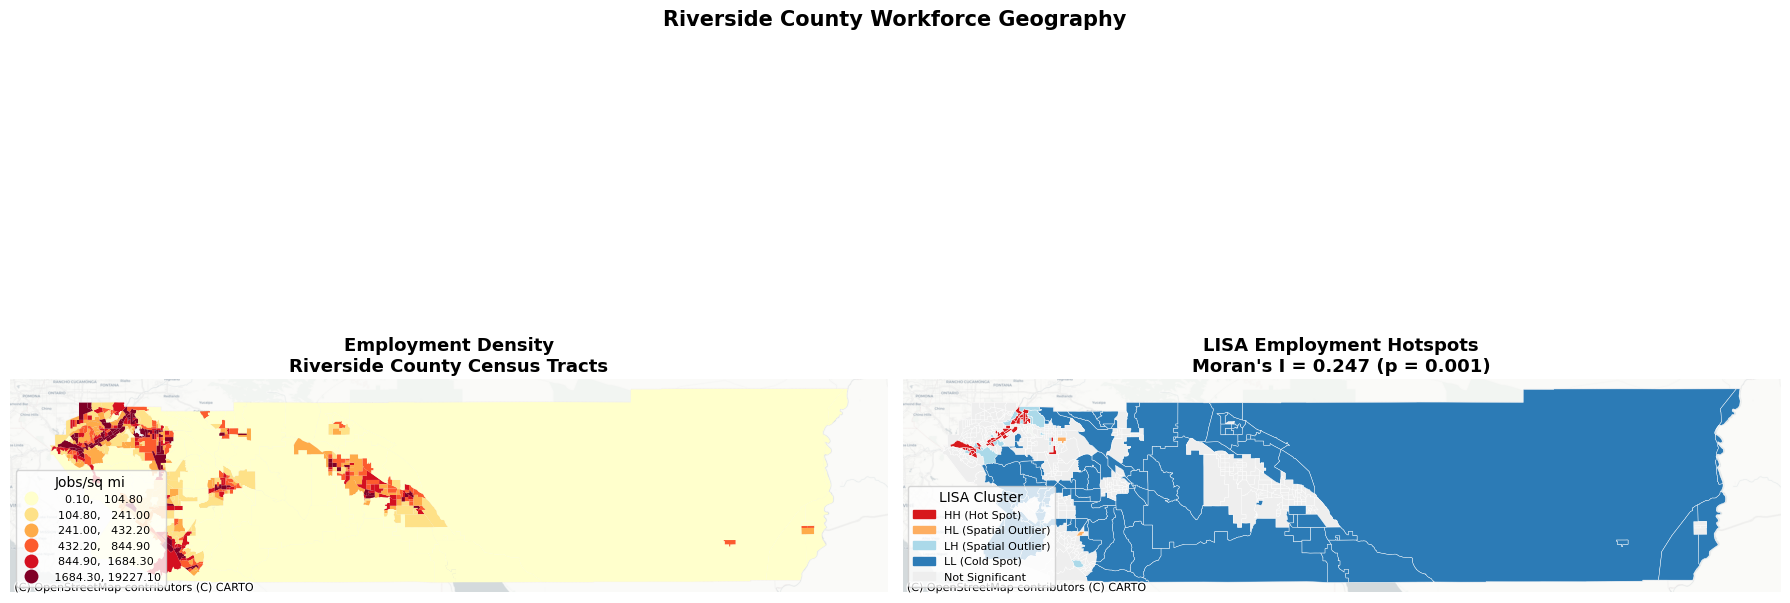

Employment density + LISA map saved


In [70]:
# Employment Density & LISA Map 

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
gdf_plot = gdf_analysis.to_crs(epsg=3857)

# Left: Job Density Choropleth
ax1 = axes[0]
gdf_plot.plot(
    column='job_density', cmap='YlOrRd', ax=ax1,
    legend=True, scheme='quantiles', k=6,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    legend_kwds={'title': 'Jobs/sq mi', 'loc': 'lower left', 'fontsize': 8}
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom=10)
ax1.set_title('Employment Density\nRiverside County Census Tracts', fontsize=13, fontweight='bold')
ax1.set_axis_off()

# Right: LISA Cluster Map
ax2 = axes[1]
lisa_colors = {
    'HH (Hot Spot)':      '#d7191c',
    'HL (Spatial Outlier)':'#fdae61',
    'LH (Spatial Outlier)':'#abd9e9',
    'LL (Cold Spot)':      '#2c7bb6',
    'Not Significant':     '#eeeeee'
}
gdf_plot['lisa_color'] = gdf_plot['lisa_cluster'].map(lisa_colors)
gdf_plot.plot(color=gdf_plot['lisa_color'], ax=ax2, linewidth=0.3, edgecolor='white')
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom=10)

legend_patches = [Patch(color=v, label=k) for k, v in lisa_colors.items()]
ax2.legend(handles=legend_patches, loc='lower left', fontsize=8, title='LISA Cluster')
ax2.set_title(f"LISA Employment Hotspots\nMoran's I = {mi.I:.3f} (p = {mi.p_sim:.3f})", fontsize=13, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Riverside County Workforce Geography', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/employment_lisa_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Employment density + LISA map saved")


In [71]:
# Download LODES OD — Commuter Origin-Destination Flows
# OD = worker home block → workplace block pairs with job counts
# main = workers who live AND work in California
# aux  = workers who work in CA but live out-of-state

OD_MAIN_URL = f"{LODES_BASE}/od/ca_od_main_JT00_{LODES_YEAR}.csv.gz"
OD_AUX_URL  = f"{LODES_BASE}/od/ca_od_aux_JT00_{LODES_YEAR}.csv.gz"

print("Downloading LODES OD data (this may take 1-2 min — ~500MB)...")
df_od_main = download_lodes(OD_MAIN_URL, "OD Main (CA residents)")
df_od_aux  = download_lodes(OD_AUX_URL,  "OD Aux  (out-of-state residents)")

if df_od_main is not None:
    # Identify Riverside County blocks
    rv_blocks_set = set(riverside_blocks.values)

    # Riverside WORKPLACE (jobs in Riverside regardless of where worker lives)
    df_od_rv_workplace = df_od_main[df_od_main['w_geocode'].isin(rv_blocks_set)].copy()

    # Add out-of-state workers who work in Riverside
    if df_od_aux is not None:
        df_od_aux_rv = df_od_aux[df_od_aux['w_geocode'].isin(rv_blocks_set)]
        df_od_rv_workplace = pd.concat([df_od_rv_workplace, df_od_aux_rv], ignore_index=True)

    # Riverside RESIDENCE (workers who live in Riverside regardless of where they work)
    df_od_rv_home = df_od_main[df_od_main['h_geocode'].isin(rv_blocks_set)].copy()

    print(f"\nOD filtered to Riverside County:")
    print(f"   Jobs IN Riverside (workplace): {df_od_rv_workplace['S000'].sum():,}")
    print(f"   Workers FROM Riverside (home): {df_od_rv_home['S000'].sum():,}")


  OD Main (CA residents): 15,041,051 rows
  OD Aux  (out-of-state residents): 206,034 rows

OD filtered to Riverside County:
   Jobs IN Riverside (workplace): 742,905
   Workers FROM Riverside (home): 944,802


In [72]:
# Commuter Inflow/Outflow Analysis by City

# Map blocks -> city using crosswalk stplcfp (place FIPS) + stplcname
place_col = [c for c in df_xwalk.columns if 'plc' in c.lower() or 'city' in c.lower() or 'place' in c.lower()]
print("Available place columns:", place_col)

name_col = place_col[1]  # stplcname — adjust index if output differs
xwalk_city = df_xwalk[['tabblk2020', name_col]].copy()
xwalk_city.columns = ['geocode', 'city_name']

# --- INFLOW: Jobs located IN each Riverside city ---
df_inflow = (
    df_od_rv_workplace
    .rename(columns={'w_geocode': 'geocode'})
    .merge(xwalk_city, on='geocode', how='left')
    .groupby('city_name')['S000'].sum()
    .reset_index()
    .rename(columns={'S000': 'jobs_inflow', 'city_name': 'city'})
)

# --- OUTFLOW: Workers who LIVE in Riverside but WORK outside Riverside ---
# Step 1: Keep only OD rows where workplace (w_geocode) is outside Riverside
df_od_commuting_out = df_od_rv_home[
    ~df_od_rv_home['w_geocode'].isin(rv_blocks_set)
].copy()

# Step 2: Map home block -> city name
df_outflow = (
    df_od_commuting_out
    .rename(columns={'h_geocode': 'geocode'})
    .merge(xwalk_city, on='geocode', how='left')
    .groupby('city_name')['S000'].sum()
    .reset_index()
    .rename(columns={'S000': 'workers_outflow', 'city_name': 'city'})
)

# --- Merge inflow + outflow ---
df_commute = (
    df_inflow.merge(df_outflow, on='city', how='outer')
    .fillna(0)
    .sort_values('jobs_inflow', ascending=False)
)
df_commute['net_flow'] = df_commute['jobs_inflow'] - df_commute['workers_outflow']
df_commute['flow_type'] = np.where(df_commute['net_flow'] > 0, 'Net Importer', 'Net Exporter')

# Filter to meaningful cities (>1000 total commute activity)
df_commute_cities = df_commute[
    (df_commute['jobs_inflow'] + df_commute['workers_outflow']) > 1000
].head(20)

print("Commuter flow analysis complete")
print(f"\nTop 10 cities by job inflow:")
print(df_commute_cities[['city','jobs_inflow','workers_outflow','net_flow','flow_type']].head(10).to_string())

Available place columns: ['stplc', 'stplcname']
Commuter flow analysis complete

Top 10 cities by job inflow:
                      city  jobs_inflow  workers_outflow  net_flow     flow_type
59      Riverside city, CA       156606            72660     83946  Net Importer
12         Corona city, CA        74767            45870     28897  Net Importer
47  Moreno Valley city, CA        57794            44613     13181  Net Importer
64       Temecula city, CA        52042            21328     30714  Net Importer
34  Jurupa Valley city, CA        34978            32710      2268  Net Importer
49       Murrieta city, CA        30804            20982      9822  Net Importer
54    Palm Desert city, CA        26330             5737     20593  Net Importer
56         Perris city, CA        25910            19070      6840  Net Importer
55   Palm Springs city, CA        25604             4956     20648  Net Importer
19       Eastvale city, CA        21185            22304     -1119  Net Exporter

In [73]:
# Shift-Share Industry Analysis 
# Compares Riverside County industry growth to California statewide averages
# Formula: Competitive Effect = E_i * (g_local_i - g_state_i)
# A positive competitive effect = Riverside growing faster than state in that sector

# Riverside County sector totals (from WAC)
rv_sector = df_tract_jobs[sector_cols].sum()
rv_total  = df_tract_jobs['total_jobs'].sum()

# California statewide sector totals (from full WAC)
# Re-aggregate CA WAC to sector totals
ca_sector = df_wac_ca[sector_cols].sum()
ca_total  = df_wac_ca['C000'].sum()

# Shift-Share components
shift_data = []
for col in sector_cols:
    E_i = rv_sector[col]           # Riverside employment in sector i
    r_i = ca_sector[col] / ca_total  # State share of sector i
    q_i = E_i / rv_total if rv_total > 0 else 0  # Riverside share of sector i

    # Location Quotient (LQ > 1 = sector is locally concentrated)
    lq = q_i / r_i if r_i > 0 else 0

    # Competitive shift = Riverside share - CA share (positive = locally advantaged)
    competitive_shift = (q_i - r_i) * rv_total

    shift_data.append({
        'sector_code': col,
        'sector': SECTOR_LABELS[col],
        'rv_jobs': int(E_i),
        'rv_share_pct': round(q_i * 100, 2),
        'ca_share_pct': round(r_i * 100, 2),
        'location_quotient': round(lq, 3),
        'competitive_shift': round(competitive_shift, 0),
        'lq_label': 'Concentrated' if lq > 1.2 else ('Average' if lq > 0.8 else 'Underrepresented')
    })

df_shift = pd.DataFrame(shift_data).sort_values('competitive_shift', ascending=False)

print("Shift-Share analysis complete")
print("\nTop 5 locally concentrated sectors (LQ > 1):")
print(df_shift[df_shift['location_quotient'] > 1][
    ['sector','rv_jobs','location_quotient','competitive_shift','lq_label']
].to_string())


Shift-Share analysis complete

Top 5 locally concentrated sectors (LQ > 1):
                      sector  rv_jobs  location_quotient  competitive_shift      lq_label
3               Construction    78084              1.887            36715.0  Concentrated
7   Transportation/Warehouse    68328              2.038            34796.0  Concentrated
17        Accommodation/Food    77791              1.385            21636.0  Concentrated
6               Retail Trade    82570              1.195            13466.0       Average
14                 Education    67228              1.093             5693.0       Average
13             Admin/Support    51071              1.054             2618.0       Average
16        Arts/Entertainment    12838              1.179             1954.0       Average
19              Public Admin    34365              1.045             1478.0       Average


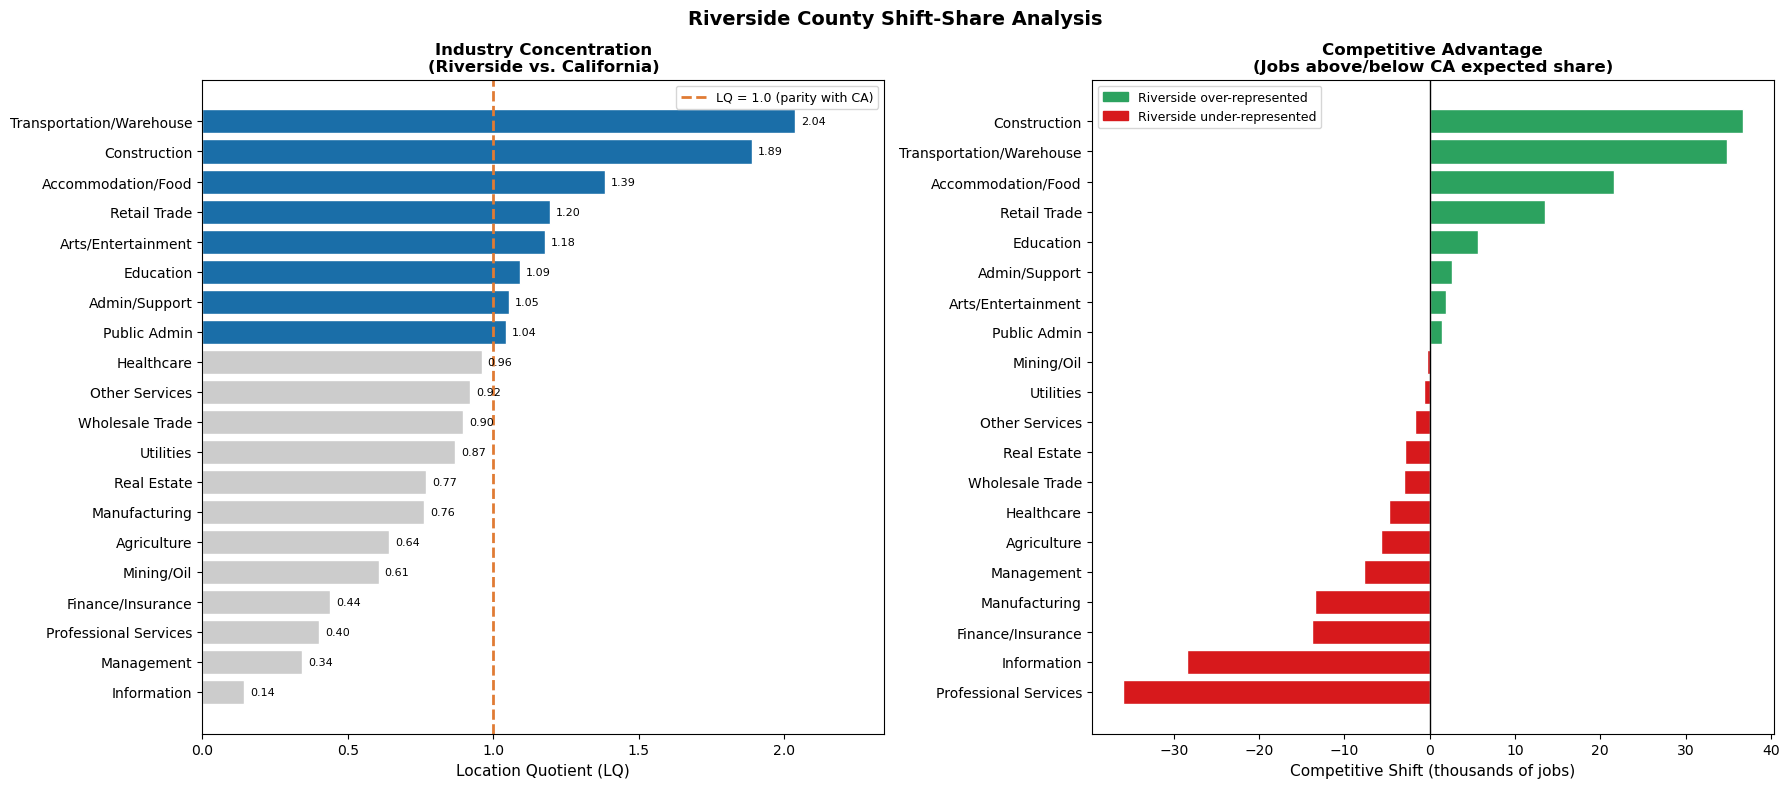

In [74]:
# Shift-Share Visualization 

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Location Quotient Bar Chart 
df_lq = df_shift.sort_values('location_quotient', ascending=True)
colors_lq = [COLORS['primary'] if lq >= 1 else '#cccccc' for lq in df_lq['location_quotient']]

ax1 = axes[0]
bars = ax1.barh(df_lq['sector'], df_lq['location_quotient'], color=colors_lq, edgecolor='white')
ax1.axvline(x=1.0, color='#e07b34', linewidth=2, linestyle='--', label='LQ = 1.0 (parity with CA)')
ax1.set_xlabel('Location Quotient (LQ)', fontsize=11)
ax1.set_title('Industry Concentration\n(Riverside vs. California)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(0, df_lq['location_quotient'].max() * 1.15)
for bar, val in zip(bars, df_lq['location_quotient']):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

# Right: Competitive Shift Chart
df_cs = df_shift.sort_values('competitive_shift', ascending=True)
colors_cs = [COLORS['accent'] if v > 0 else COLORS['danger'] for v in df_cs['competitive_shift']]

ax2 = axes[1]
ax2.barh(df_cs['sector'], df_cs['competitive_shift'] / 1000,
         color=colors_cs, edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_xlabel('Competitive Shift (thousands of jobs)', fontsize=11)
ax2.set_title('Competitive Advantage\n(Jobs above/below CA expected share)', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(color=COLORS['accent'], label='Riverside over-represented'),
              Patch(color=COLORS['danger'], label='Riverside under-represented')]
ax2.legend(handles=legend_els, fontsize=9)

plt.suptitle('Riverside County Shift-Share Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shift_share_chart.png', dpi=150, bbox_inches='tight')
plt.show()


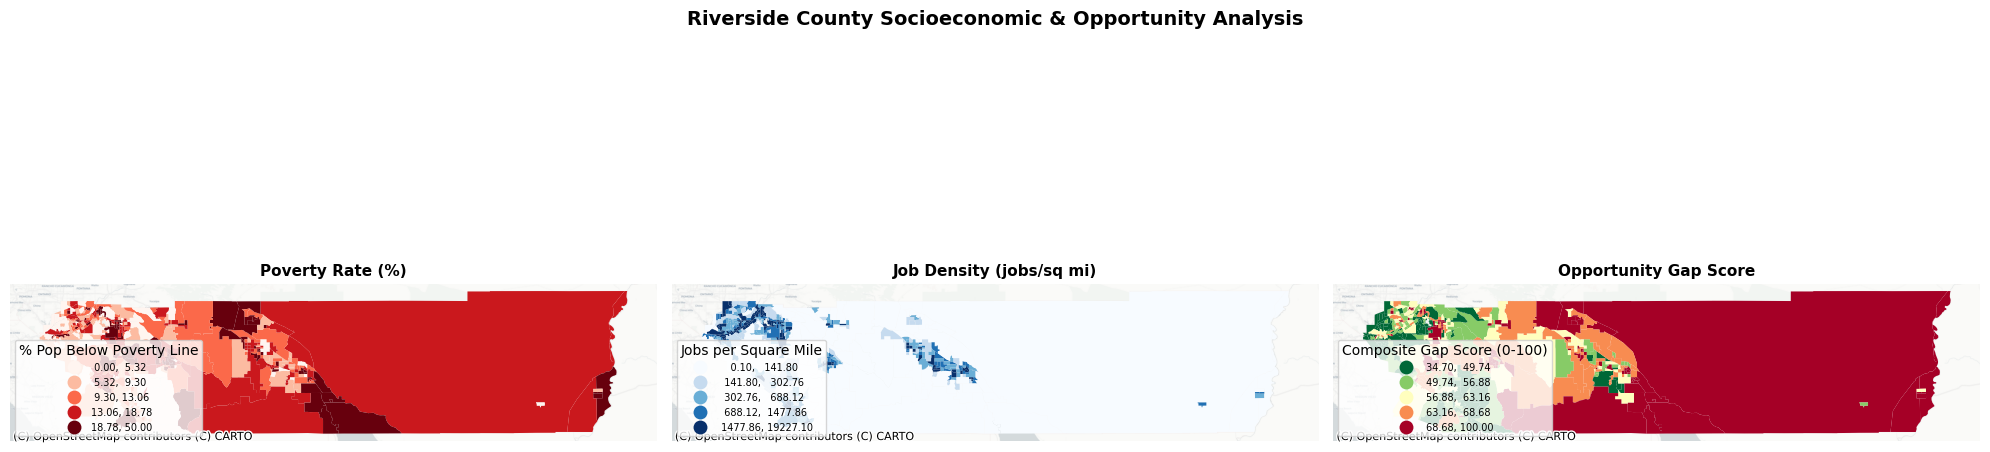

In [75]:
# Opportunity Gap Score Map
# Combines poverty rate + job density + income into a single gap score
# High score = area that likely needs targeted economic development investment

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
gdf_plot = gdf_analysis.to_crs(epsg=3857)

plot_configs = [
    ('poverty_rate',     'Poverty Rate (%)',        'Reds',  '% Pop Below Poverty Line'),
    ('job_density',      'Job Density (jobs/sq mi)', 'Blues', 'Jobs per Square Mile'),
    ('opportunity_gap',  'Opportunity Gap Score',    'RdYlGn_r', 'Composite Gap Score (0-100)'),
]

for ax, (col, title, cmap, legend_title) in zip(axes, plot_configs):
    gdf_plot[col] = pd.to_numeric(gdf_plot[col], errors='coerce')
    gdf_plot.plot(
        column=col, cmap=cmap, ax=ax, legend=True,
        scheme='quantiles', k=5,
        missing_kwds={'color': 'lightgrey'},
        legend_kwds={'title': legend_title, 'loc': 'lower left', 'fontsize': 7}
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Riverside County Socioeconomic & Opportunity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/opportunity_gap_map.png', dpi=150, bbox_inches='tight')
plt.show()



In [76]:
# Interactive Folium Map — Multi-Layer Dashboard 
# Standalone HTML map with layer controls (shareable without a server)

import folium
from folium import Choropleth, GeoJson
from folium.plugins import MeasureControl, Fullscreen

# Convert to WGS84 for Folium
gdf_folium = gdf_analysis.to_crs(epsg=4326).copy()

# Get county center
center_lat = gdf_folium.geometry.centroid.y.mean()
center_lon = gdf_folium.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10,
               tiles='CartoDB positron', prefer_canvas=True)

# Layer 1: Employment Density 
Choropleth(
    geo_data=gdf_folium.__geo_interface__,
    data=gdf_folium.set_index('GEOID')['job_density'].dropna(),
    columns=['GEOID', 'job_density'],
    key_on='feature.properties.GEOID',
    fill_color='YlOrRd', fill_opacity=0.7, line_opacity=0.3,
    legend_name='Job Density (jobs/sq mi)',
    name='Employment Density',
    highlight=True,
).add_to(m)

# Layer 2: LISA Clusters 
lisa_color_map = {
    'HH (Hot Spot)': '#d7191c', 'HL (Spatial Outlier)': '#fdae61',
    'LH (Spatial Outlier)': '#abd9e9', 'LL (Cold Spot)': '#2c7bb6',
    'Not Significant': '#cccccc'
}
lisa_group = folium.FeatureGroup(name='LISA Employment Clusters', show=False)
for _, row in gdf_folium.iterrows():
    color = lisa_color_map.get(str(row.get('lisa_cluster', '')), '#cccccc')
    popup_html = (f"<b>{row.get('NAME', 'N/A')}</b><br>"
                  f"LISA: {row.get('lisa_cluster', 'N/A')}<br>"
                  f"Jobs: {int(row.get('total_jobs', 0) or 0):,}<br>"
                  f"Dominant: {row.get('dominant_sector', 'N/A')}")
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda f, c=color: {
            'fillColor': c, 'color': 'white',
            'weight': 0.5, 'fillOpacity': 0.75
        },
        tooltip=popup_html
    ).add_to(lisa_group)
lisa_group.add_to(m)

# Layer 3: Opportunity Gap 
opp_group = folium.FeatureGroup(name='Opportunity Gap Score', show=False)
Choropleth(
    geo_data=gdf_folium.__geo_interface__,
    data=gdf_folium.set_index('GEOID')['opportunity_gap'].dropna(),
    columns=['GEOID', 'opportunity_gap'],
    key_on='feature.properties.GEOID',
    fill_color='RdYlGn_r', fill_opacity=0.75, line_opacity=0.2,
    legend_name='Opportunity Gap Score (0=low, 100=high need)',
    name='Opportunity Gap',
    show=False,
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MeasureControl().add_to(m)
Fullscreen().add_to(m)

# Save
FOLIUM_OUTPUT = 'outputs/rv_county_bi_dashboard_folium.html'
m.save(FOLIUM_OUTPUT)

# Render inline in Colab
from IPython.display import IFrame
IFrame(FOLIUM_OUTPUT, width=900, height=600)


In [77]:
# ARCGIS GEOJSON EXPORT (bypass — no LODES required) 
# Builds a minimal GeoDataFrame from TIGER + Census ACS only.
# LODES-derived fields (jobs, density, shift-share) will be 0/null
# and can be added later once the LEHD DNS issue is resolved.

import requests, io
import numpy as np
import pandas as pd
import geopandas as gpd

# 1. Download TIGER tract boundaries 
print("Downloading TIGER boundaries...")
TIGER_URL = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_06_tract_500k.zip"
TIGER_LOCAL = "/tmp/ca_tracts.zip"
r = requests.get(TIGER_URL, timeout=120)
with open(TIGER_LOCAL, 'wb') as f:
    f.write(r.content)
gdf_tracts = gpd.read_file(f"zip://{TIGER_LOCAL}")
gdf_rv = gdf_tracts[gdf_tracts['COUNTYFP'] == '065'].copy()
gdf_rv['GEOID'] = gdf_rv['GEOID'].astype(str).str.zfill(11)
print(f"  Tracts loaded: {len(gdf_rv)}")

# 2. Pull Census ACS demographics 
print("Pulling Census ACS data...")
ACS_VARS = {
    'B19013_001E': 'median_income',
    'B01003_001E': 'total_pop',
    'B17001_002E': 'poverty_count',
    'B23025_004E': 'employed_civlabor',
}
var_str = ','.join(ACS_VARS.keys())
r = requests.get(
    f"https://api.census.gov/data/2021/acs/acs5",
    params={'get': f'NAME,{var_str}', 'for': 'tract:*', 'in': 'state:06 county:065'},
    timeout=60
)
data = r.json()
df_acs = pd.DataFrame(data[1:], columns=data[0])
df_acs['GEOID'] = df_acs['state'] + df_acs['county'] + df_acs['tract']
df_acs['GEOID'] = df_acs['GEOID'].str.zfill(11)
for col in ACS_VARS:
    df_acs[ACS_VARS[col]] = pd.to_numeric(df_acs[col], errors='coerce').replace(-666666999, np.nan)
df_acs['poverty_rate'] = (df_acs['poverty_count'] / df_acs['total_pop'] * 100).round(1)
print(f"  ACS tracts pulled: {len(df_acs)}")

# 3. Merge and export 
gdf_export = gdf_rv.merge(df_acs[['GEOID','median_income','total_pop','poverty_rate']], on='GEOID', how='left')
gdf_export = gdf_export.to_crs(epsg=4326)

# Placeholder LODES fields (fill in after DNS fix)
gdf_export['total_jobs']      = 0
gdf_export['job_density']     = 0.0
gdf_export['dominant_sector'] = 'Pending LODES data'
gdf_export['opportunity_gap'] = np.nan

OUT = '/tmp/rv_county_tracts_portfolio.geojson'
gdf_export[['GEOID','NAME','median_income','total_pop','poverty_rate',
            'total_jobs','job_density','dominant_sector','opportunity_gap',
            'geometry']].to_file(OUT, driver='GeoJSON')

print(f"\nGeoJSON exported: {OUT}")
print(f"Fields: GEOID, NAME, median_income, total_pop, poverty_rate, geometry")
print(f"  (total_jobs / job_density / opportunity_gap = 0 until LODES loads)")
print("\nNext: upload to https://www.arcgis.com/home/content.html")

  Tracts loaded: 518
Pulling Census ACS data...
  ACS tracts pulled: 518

GeoJSON exported: /tmp/rv_county_tracts_portfolio.geojson
Fields: GEOID, NAME, median_income, total_pop, poverty_rate, geometry
  (total_jobs / job_density / opportunity_gap = 0 until LODES loads)

Next: upload to https://www.arcgis.com/home/content.html


In [78]:
import shutil
shutil.copy('/tmp/rv_county_tracts_portfolio.geojson', 
            './rv_county_tracts_portfolio.geojson')
print("Saved to project folder")

Saved to project folder


In [79]:
# ArcGIS Online Embed 
# Bridges your ArcGIS JS API portfolio track.
# Option A: Embed a public SCAG/CA ArcGIS Online map as an iframe
# Option B: After publishing your own layer to ArcGIS Online, replace the ITEM_ID below

from IPython.display import HTML

AGOL_ITEM_ID = '861e2664f5fb4339b6927f11c0332e1e'  # Replace after publishing

# Export tract data to GeoJSON for ArcGIS Online upload
geojson_export = gdf_analysis.to_crs(epsg=4326)[
    ['GEOID', 'total_jobs', 'job_density', 'dominant_sector',
     'opportunity_gap', 'median_income', 'poverty_rate', 'lisa_cluster', 'geometry']
].copy()
geojson_export = geojson_export[geojson_export.geometry.notna()]
geojson_path = '/tmp/rv_county_tracts_portfolio.geojson'
geojson_export.to_file(geojson_path, driver='GeoJSON')
print('GeoJSON exported for ArcGIS Online upload: ' + geojson_path)
print('  -> Upload to: https://www.arcgis.com/home/content.html')
print('  -> Then update AGOL_ITEM_ID above with your published item ID')

# ArcGIS Online embed HTML (works once item is published as public)
embed_src = 'https://www.arcgis.com/apps/mapviewer/index.html?webmap=' + AGOL_ITEM_ID
item_link = 'https://www.arcgis.com/home/item.html?id=' + AGOL_ITEM_ID
arcgis_embed_html = (
    '<div style="border:2px solid #1a6ea8;border-radius:8px;overflow:hidden;margin:10px 0;">'
    '<div style="background:#1a6ea8;color:white;padding:8px 12px;font-family:Arial;font-weight:bold;">'
    'Riverside County Workforce Map -- ArcGIS Online</div>'
    '<iframe src="' + embed_src + '" width="100%" height="500" frameborder="0"'
    ' style="display:block;" allow="geolocation"></iframe>'
    '<div style="background:#f0f4f8;padding:6px 12px;font-family:Arial;font-size:11px;color:#555;">'
    'Interactive map powered by ArcGIS Online | '
    '<a href="' + item_link + '" target="_blank">View full map</a></div></div>'
)
HTML(arcgis_embed_html)


GeoJSON exported for ArcGIS Online upload: /tmp/rv_county_tracts_portfolio.geojson
  -> Upload to: https://www.arcgis.com/home/content.html
  -> Then update AGOL_ITEM_ID above with your published item ID


In [82]:
# Plotly Dash Interactive Dashboard 
# Full 4-panel interactive dashboard — run locally or deploy to Render/Heroku

from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
import json
import os, signal

# Free port 8052 if already in use
try:
    import psutil
    for proc in psutil.process_iter(['pid', 'connections']):
        for conn in (proc.info['connections'] or []):
            if conn.laddr.port == 8052:
                os.kill(proc.info['pid'], signal.SIGKILL)
                print(f"Killed PID {proc.info['pid']} on port 8052")
except Exception as e:
    print(f"Port cleanup: {e}")

# Prepare GeoJSON for Plotly choropleth
gdf_dash = gdf_analysis.to_crs(epsg=4326).copy()
gdf_dash['GEOID'] = gdf_dash['GEOID'].astype(str)
geojson_dict = json.loads(gdf_dash[['GEOID','geometry']].to_json())

# Clean numeric cols for Plotly
for col in ['total_jobs','job_density','median_income','poverty_rate','opportunity_gap']:
    gdf_dash[col] = pd.to_numeric(gdf_dash[col], errors='coerce').fillna(0)


app = Dash(__name__)

LAYER_OPTIONS = [
    {'label': 'Job Density (jobs/sq mi)',    'value': 'job_density'},
    {'label': 'Total Jobs',                  'value': 'total_jobs'},
    {'label': 'Median Household Income ($)', 'value': 'median_income'},
    {'label': 'Poverty Rate (%)',            'value': 'poverty_rate'},
    {'label': 'Opportunity Gap Score',       'value': 'opportunity_gap'},
]

app.layout = html.Div([
    # Header 
    html.Div([
        html.H2("Riverside County Business Intelligence Dashboard",
                style={'color': 'white', 'margin': '0 0 4px 0', 'fontSize': '20px'}),
        html.P("Workforce, Industry, and Opportunity Analysis | LEHD LODES + Census ACS",
               style={'color': '#cce4f7', 'margin': 0, 'fontSize': '12px'})
    ], style={'background': '#1a6ea8', 'padding': '14px 20px'}),

    # Controls
    html.Div([
        html.Div([
            html.Label("Map Layer:", style={'fontWeight': 'bold', 'fontSize': '12px'}),
            dcc.Dropdown(id='layer-select', options=LAYER_OPTIONS,
                         value='job_density', clearable=False,
                         style={'fontSize': '12px', 'width': '280px'})
        ], style={'marginRight': '30px'}),
        html.Div([
            html.Label("Top Cities (Commute Chart):", style={'fontWeight': 'bold', 'fontSize': '12px'}),
            dcc.Slider(id='city-slider', min=5, max=20, step=5, value=10,
                       marks={5:'5', 10:'10', 15:'15', 20:'20'})
        ], style={'width': '220px'})
    ], style={'display': 'flex', 'alignItems': 'center', 'padding': '12px 20px',
              'background': '#f0f4f8', 'borderBottom': '1px solid #ddd'}),

    # Main grid
    html.Div([
        # Left: map
        html.Div([
            dcc.Graph(id='choropleth-map', style={'height': '450px'})
        ], style={'width': '55%', 'paddingRight': '10px'}),

        # Right: charts
        html.Div([
            dcc.Graph(id='sector-bar',    style={'height': '215px'}),
            dcc.Graph(id='commute-chart', style={'height': '225px'}),
        ], style={'width': '45%'})
    ], style={'display': 'flex', 'padding': '12px 20px'}),

    # Bottom: shift-share + opportunity
    html.Div([
        html.Div([dcc.Graph(id='shift-share-chart', style={'height': '280px'})],
                 style={'width': '50%', 'paddingRight': '10px'}),
        html.Div([dcc.Graph(id='opportunity-scatter', style={'height': '280px'})],
                 style={'width': '50%'})
    ], style={'display': 'flex', 'padding': '0 20px 20px 20px'}),

], style={'fontFamily': 'Arial, sans-serif', 'background': 'white'})

# Callbacks 
@app.callback(
    Output('choropleth-map', 'figure'),
    Input('layer-select', 'value')
)
def update_map(layer):
    label_map = {o['value']: o['label'] for o in LAYER_OPTIONS}
    color_scales = {
        'job_density': 'YlOrRd', 'total_jobs': 'YlOrRd',
        'median_income': 'Blues', 'poverty_rate': 'Reds',
        'opportunity_gap': 'RdYlGn_r'
    }
    fig = px.choropleth_mapbox(
        gdf_dash, geojson=geojson_dict,
        locations='GEOID', featureidkey='properties.GEOID',
        color=layer, color_continuous_scale=color_scales.get(layer, 'Viridis'),
        mapbox_style='carto-positron', zoom=8.5,
        center={'lat': 33.9, 'lon': -116.8},
        opacity=0.7,
        hover_data={'total_jobs': True, 'median_income': True,
                    'dominant_sector': True, 'opportunity_gap': True},
        labels={layer: label_map.get(layer, layer)}
    )
    fig.update_layout(margin={'r':0,'t':30,'l':0,'b':0},
                      title_text=label_map.get(layer, layer),
                      title_x=0.01, title_font_size=13)
    return fig

@app.callback(
    Output('sector-bar', 'figure'),
    Input('layer-select', 'value')
)
def update_sector_bar(_):
    top_sectors = (
        df_shift.nlargest(10, 'rv_jobs')[['sector', 'rv_jobs', 'location_quotient']]
    )
    fig = px.bar(top_sectors, x='rv_jobs', y='sector', orientation='h',
                 color='location_quotient', color_continuous_scale='RdBu',
                 color_continuous_midpoint=1.0,
                 title='Top 10 Sectors by Employment',
                 labels={'rv_jobs': 'Jobs', 'sector': '',
                         'location_quotient': 'LQ vs CA'})
    fig.update_layout(margin={'t': 35, 'b': 5, 'l': 5, 'r': 5},
                      height=210, font_size=10)
    return fig

@app.callback(
    Output('commute-chart', 'figure'),
    Input('city-slider', 'value')
)
def update_commute(n_cities):
    df_top = df_commute_cities.head(n_cities)
    fig = go.Figure()
    fig.add_bar(x=df_top['city'], y=df_top['jobs_inflow'],
                name='Jobs In (inflow)', marker_color='#1a6ea8')
    fig.add_bar(x=df_top['city'], y=df_top['workers_outflow'],
                name='Workers Out (outflow)', marker_color='#e07b34')
    fig.update_layout(barmode='group', title='Commuter Inflow vs Outflow by City',
                      height=220, margin={'t':35,'b':5,'l':5,'r':5},
                      font_size=9, legend=dict(orientation='h', y=1.15))
    return fig

@app.callback(
    Output('shift-share-chart', 'figure'),
    Input('layer-select', 'value')
)
def update_shift(_):
    fig = px.bar(
        df_shift.sort_values('competitive_shift'),
        x='competitive_shift', y='sector', orientation='h',
        color='location_quotient', color_continuous_scale='RdYlGn',
        title='LQ & Competitive Shift: Riverside vs. CA',
        labels={'competitive_shift': 'Competitive Shift (jobs above/below CA expected share)',
                'sector': '', 'location_quotient': 'Location Quotient (LQ)'}
    )
    fig.add_vline(x=0, line_color='black', line_width=1)
    fig.update_layout(height=270, margin={'t':35,'b':5,'l':5,'r':5}, font_size=9)
    return fig

@app.callback(
    Output('opportunity-scatter', 'figure'),
    Input('layer-select', 'value')
)
def update_opportunity(_):
    fig = px.scatter(
        gdf_dash.dropna(subset=['median_income','opportunity_gap','total_jobs']),
        x='median_income', y='opportunity_gap',
        size='total_pop', color='poverty_rate',
        color_continuous_scale='Reds',
        hover_data=['NAME', 'dominant_sector', 'total_jobs'],
        title='Income vs. Opportunity Gap by Tract',
        labels={'median_income': 'Median Household Income ($)',
                'opportunity_gap': 'Opportunity Gap Score',
                'poverty_rate': 'Poverty Rate (%)'}
    )
    fig.update_layout(height=270, margin={'t':35,'b':5,'l':5,'r':5}, font_size=9)
    return fig

# Run 
print("Dash app defined. Starting server...")
print("   -> Open: http://127.0.0.1:8052/")
print("   (In Colab, use: from google.colab.output import eval_js)")
print("   (     proxy_url = eval_js('google.colab.kernel.proxyPort(8052)'))")

if __name__ == '__main__':
    app.run(debug=False, port=8052)

Port cleanup: invalid attr name 'connections'
Dash app defined. Starting server...
   -> Open: http://127.0.0.1:8052/
   (In Colab, use: from google.colab.output import eval_js)
   (     proxy_url = eval_js('google.colab.kernel.proxyPort(8052)'))


[2026-04-09 12:58:11,473] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Export Static Plotly HTML (no server needed) 
# Generate a standalone HTML file from key figures for GitHub Pages / portfolio

import plotly.io as pio

figures = {}

# 1) Employment density choropleth (static snapshot)
fig_density = px.choropleth_mapbox(
    gdf_dash, geojson=geojson_dict,
    locations='GEOID', featureidkey='properties.GEOID',
    color='job_density', color_continuous_scale='YlOrRd',
    mapbox_style='carto-positron', zoom=8.5,
    center={'lat': 33.9, 'lon': -116.8}, opacity=0.75,
    hover_data={'total_jobs': True, 'dominant_sector': True, 'opportunity_gap': True},
    title='<b>Riverside County Employment Density</b> | Census Tract Level | LODES 2021'
)
fig_density.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
figures['employment_density'] = fig_density

# 2) Commuter flow chart
fig_commute = go.Figure()
df_top10 = df_commute_cities.head(12)
fig_commute.add_bar(x=df_top10['city'], y=df_top10['jobs_inflow'],
                    name='Jobs Inflow', marker_color='#1a6ea8')
fig_commute.add_bar(x=df_top10['city'], y=df_top10['workers_outflow'],
                    name='Workers Outflow', marker_color='#e07b34')
fig_commute.update_layout(
    barmode='group',
    title='<b>Commuter Inflow vs. Outflow by City</b> | Riverside County 2021',
    xaxis_tickangle=-35,
    margin=dict(b=120),
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.02,
        xanchor='right',  x=1
    )
)
figures['commuter_flow'] = fig_commute

# 3) Shift-share
fig_shift = px.bar(
    df_shift.sort_values('competitive_shift'),
    x='competitive_shift', y='sector', orientation='h',
    color='location_quotient', color_continuous_scale='RdYlGn',
    title='<b>Location Quotient & Competitive Shift</b> | Riverside vs. California Industry Mix',
    labels={
        'competitive_shift': 'Competitive Shift (jobs above/below CA expected share)',
        'sector': 'NAICS Sector',
        'location_quotient': 'Location Quotient (LQ)'
    }
)
fig_shift.add_vline(x=0, line_color='black')
fig_shift.update_layout(
    margin=dict(l=160, b=80),
    annotations=[dict(
        text=(
            'Bar length = jobs above or below CA expected share (competitive shift). '
            'Color = Location Quotient — LQ > 1 means locally concentrated vs. CA.'
        ),
        xref='paper', yref='paper',
        x=0, y=-0.18,
        showarrow=False,
        font=dict(size=10, color='#555'),
        align='left'
    )]
)
figures['shift_share'] = fig_shift

# Write combined HTML
OUTPUT_HTML = 'outputs/rv_county_bi_dashboard.html'
with open(OUTPUT_HTML, 'w') as f:
    f.write("""<!DOCTYPE html>
<html>
<head>
  <meta charset='utf-8'>
  <title>Riverside County Business Intelligence Dashboard</title>
  <style>
    body { font-family: Arial, sans-serif; margin: 0; background: #f8fafc; }
    .header { background: #1a6ea8; color: white; padding: 20px 30px; }
    .header h1 { margin: 0 0 6px 0; font-size: 22px; }
    .header p  { margin: 0; font-size: 13px; color: #cde; }
    .chart-container { margin: 16px; background: white;
                       border-radius: 8px; box-shadow: 0 1px 4px rgba(0,0,0,0.1);
                       padding: 10px; }
  </style>
</head>
<body>
  <div class='header'>
    <h1>Riverside County Business Intelligence Dashboard</h1>
    <p>Workforce Geography & Economic Analysis | LEHD LODES + Census ACS 5-Year | 2021</p>
  </div>
""")
    for name, fig in figures.items():
        html_fig = pio.to_html(fig, full_html=False, include_plotlyjs='cdn')
        f.write(f"<div class='chart-container'>{html_fig}</div>\n")
    f.write("</body></html>")

print(f"Standalone HTML dashboard exported: {OUTPUT_HTML}")
print(f"   -> Upload to GitHub Pages or share directly")

Standalone HTML dashboard exported: outputs/rv_county_bi_dashboard.html
   -> Upload to GitHub Pages or share directly


[2026-04-09 12:58:52,174] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/rv-bi-dashboard/lib/python3.11/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^